In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv('CC General.csv')

In [3]:
df.shape

(8950, 18)

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
numerical_features = df.select_dtypes(include=[np.number]).columns
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].mean())
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [7]:
df.sample(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7921,C18136,184.212569,1.000000,1292.76,653.76,639.0,0.000000,1.000000,1.000000,0.666667,0.000000,0,57,7500.0,1132.873950,166.655851,0.500000,12
8702,C18939,60.816514,0.818182,900.00,0.00,900.0,0.000000,0.750000,0.000000,0.750000,0.000000,0,9,1000.0,1208.785022,174.822875,0.777778,12
8615,C18849,85.900738,1.000000,0.00,0.00,0.0,278.348105,0.000000,0.000000,0.000000,0.250000,3,0,500.0,193.747321,146.858723,0.000000,12
2044,C12108,1709.693956,1.000000,2.00,2.00,0.0,5246.296449,0.083333,0.083333,0.000000,0.250000,6,1,2500.0,4678.254753,464.860442,0.083333,12
8170,C18390,46.996535,0.272727,0.00,0.00,0.0,2370.681355,0.000000,0.000000,0.000000,0.166667,2,0,3500.0,5679.772590,82.578321,0.000000,12
6723,C16911,179.357206,1.000000,497.15,497.15,0.0,0.000000,0.416667,0.416667,0.000000,0.000000,0,6,1200.0,291.121154,180.093054,0.000000,12
8189,C18409,114.297852,0.909091,994.54,249.54,745.0,0.000000,0.833333,0.333333,0.750000,0.000000,0,18,1000.0,1099.568918,163.756802,0.444444,12
4467,C14591,300.395286,1.000000,394.95,277.95,117.0,0.000000,0.916667,0.250000,0.750000,0.000000,0,33,6000.0,339.702306,175.285790,0.000000,12
1100,C11136,5858.947560,1.000000,896.18,896.18,0.0,4222.003137,0.166667,0.166667,0.000000,0.666667,12,5,7000.0,3948.663657,1493.652513,0.000000,12
368,C10380,7760.940543,1.000000,0.00,0.00,0.0,3423.085934,0.000000,0.000000,0.000000,0.500000,10,0,8000.0,2845.010795,2459.741299,0.000000,12


In [8]:
x = df[numerical_features]

In [9]:
scaler = StandardScaler()
sc_x = scaler.fit_transform(x)

In [10]:
wcss = []
for k in range(1,20):
    clustering = KMeans(n_clusters=k,init='k-means++')
    clustering.fit(sc_x)
    wcss.append(clustering.inertia_)

In [11]:
wcss

[152150.00000000006,
 128957.90955338099,
 111986.5663972189,
 99074.42270603366,
 92139.80256173298,
 88909.71839105495,
 82072.88638942386,
 76597.94082490588,
 71097.28037922597,
 70259.82344082411,
 64153.78991083003,
 61366.82277501805,
 59660.633312942366,
 57669.50472925093,
 56175.38498101073,
 54271.25227625151,
 53587.2162929808,
 52961.69103837536,
 52117.86944517167]

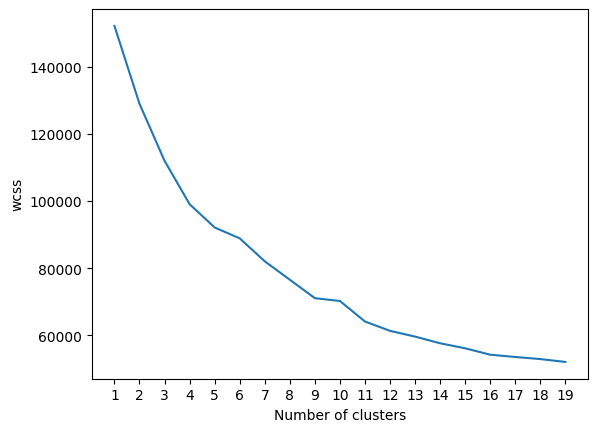

In [12]:
plt.plot(range(1,20),wcss)
plt.xticks(range(1,20))
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [13]:
from sklearn.metrics import silhouette_score
sil_scores = []
optimal_k = 2
max_sil_score = -1

for k in range(2,20):
    cluster = KMeans(n_clusters=k, random_state=42)
    cluster_labels = cluster.fit_predict(sc_x)
    score = silhouette_score(sc_x, cluster_labels)
    sil_scores.append(score)
    if score > max_sil_score:
        max_sil_score = score
        optimal_k = k

In [14]:
a = KMeans(n_clusters=optimal_k, random_state=42)
b = a.fit_predict(sc_x)
print(silhouette_score(sc_x, b))

0.2799129722709682


In [15]:
print(optimal_k)

2


In [16]:
sil_scores

[0.2799129722709682,
 0.20676101192444304,
 0.1663920865670164,
 0.19234566924305485,
 0.202755081788085,
 0.19486979124151635,
 0.1899728747613868,
 0.2016552706516606,
 0.2205181120683996,
 0.22096575441333918,
 0.21859624560726057,
 0.2183443270761705,
 0.218486306070994,
 0.21869945617768544,
 0.21612037118473312,
 0.21632849165772905,
 0.21814544133011923,
 0.20240078578400722]

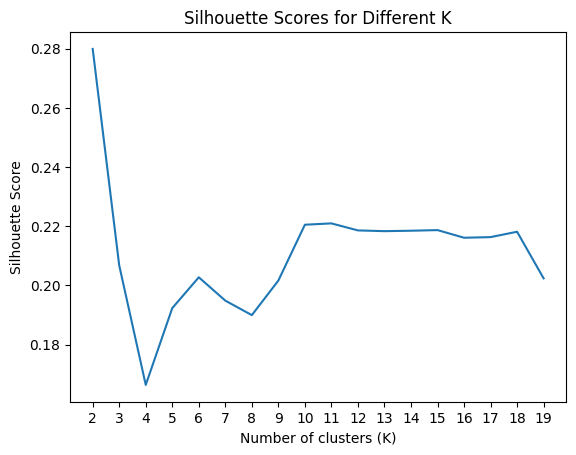

In [17]:
plt.plot(range(2, 20), sil_scores)
plt.xticks(range(2, 20))
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different K")
plt.show()

In [18]:
# for finding the value of k automatically
from kneed import KneeLocator
kl = KneeLocator(range(1,20),wcss,curve='convex',direction='decreasing') # if wcss graph increasing then take curve='concave'
print(kl.elbow)

11


In [19]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(sc_x)

In [20]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,864.206542,0.000000,6,1
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,1
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,1


In [21]:
df['Cluster'].value_counts()

Cluster
1    7095
0    1855
Name: count, dtype: int64

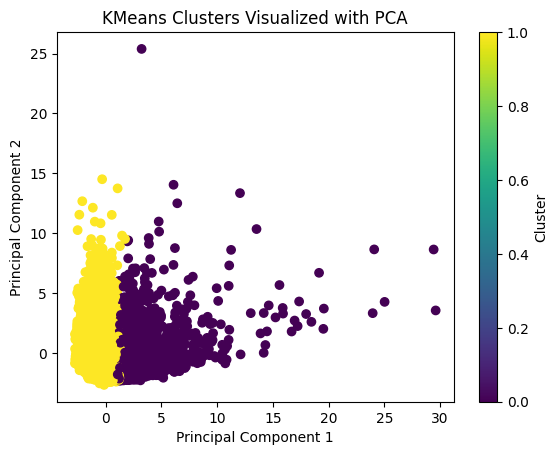

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(sc_x)

# Plot the clusters
# plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=df['Cluster'], cmap='viridis')
plt.title('KMeans Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [23]:
print(df.groupby('Cluster').mean(numeric_only=True))

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        2148.810535           0.979719  3370.375445       2079.231811   
1        1411.699248           0.850485   384.303990        203.712397   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                   1291.467084    762.707615             0.938106   
1                    180.885691   1035.387432             0.373284   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                          0.588824                          0.713334   
1                          0.101442                          0.273218   

         CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  \
Cluster                                                      

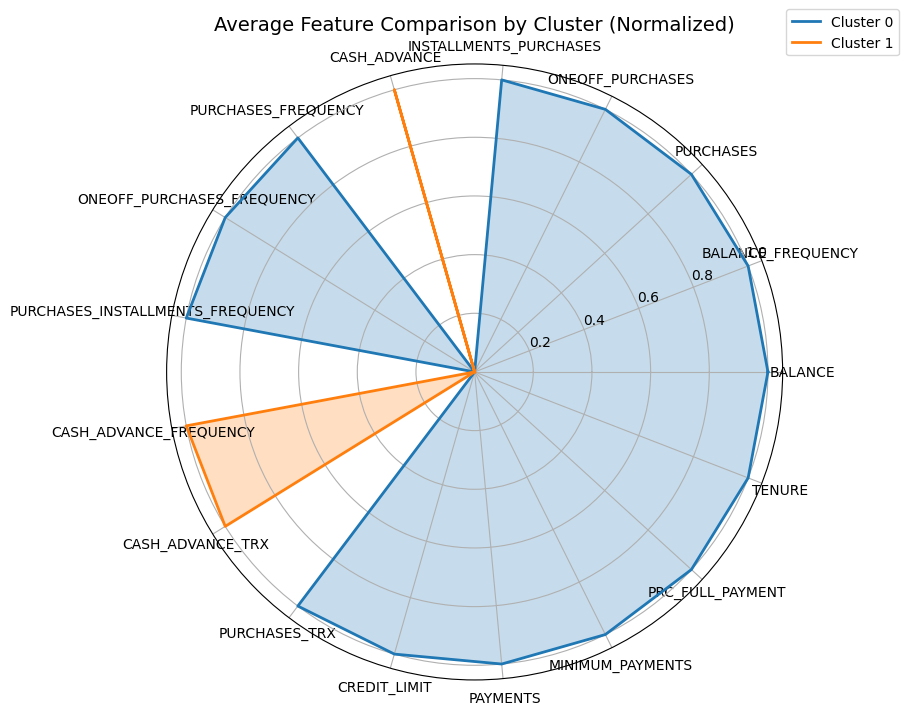

In [24]:
# Radar chart

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Get the mean values per cluster (only numeric)
cluster_means = df.groupby('Cluster').mean(numeric_only=True)

# Step 2: Normalize the values (optional but helps with scale differences)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

# Step 3: Setup for radar chart
features = cluster_means_scaled.columns.tolist()
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # repeat first angle to close the circle

# Step 4: Prepare data for plotting
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

for cluster in cluster_means_scaled.index:
    values = cluster_means_scaled.loc[cluster].tolist()
    values += values[:1]  # repeat first value to close the loop
    ax.plot(angles, values, label=f'Cluster {cluster}', linewidth=2)
    ax.fill(angles, values, alpha=0.25)

# Step 5: Set axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)
ax.set_title('Average Feature Comparison by Cluster (Normalized)', size=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))



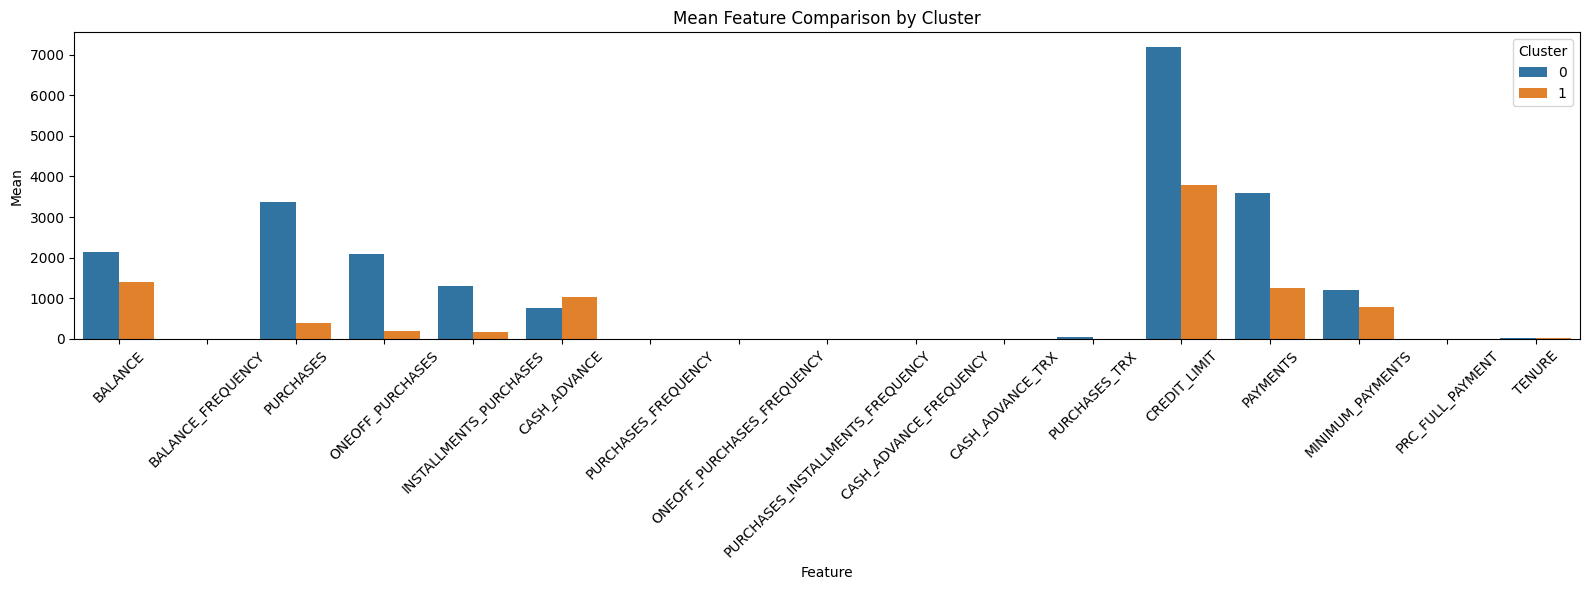

In [ ]:
import seaborn as sns

# Melt the data for seaborn
mean_df = cluster_means.reset_index().melt(id_vars='Cluster', var_name='Feature', value_name='Mean')
# melt function is used to reshape the data. It converts the DataFrame from a wide format to a long format.

plt.figure(figsize=(16, 6))
sns.barplot(data=mean_df, x='Feature', y='Mean', hue='Cluster')
plt.title('Mean Feature Comparison by Cluster')
plt.xticks(rotation=45)
plt.tight_layout()  
plt.show()


In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
x = df[numerical_features]
y = df['Cluster']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [29]:
regressor = RandomForestClassifier()

In [30]:
parameters = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

In [31]:
rcv = GridSearchCV(regressor, param_grid=parameters, cv=5, scoring='r2')

In [32]:
rcv.fit(x_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [33]:
rcv.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

In [34]:
print(rcv.best_score_)

0.8794841650935059


In [35]:
y_pred = rcv.predict(x_test)

In [36]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [37]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.8587923528298316
MAE: 0.023681858802502235
MSE: 0.023681858802502235


In [38]:
from sklearn.metrics import confusion_matrix,classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       477
           1       0.98      0.99      0.98      1761

    accuracy                           0.98      2238
   macro avg       0.97      0.96      0.96      2238
weighted avg       0.98      0.98      0.98      2238

Confusion Matrix:
[[ 447   30]
 [  23 1738]]
